# Purpose

The purpose of this example notebook is to show how to use the `spectra` package for spectrum analysis and calculating the normalized dose as a function of `z`. This notebook will walk through a more complex example useing multiple absorbers and multiple wavelength sources.

# Imports

In [1]:
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams
from spectra.normalizeddose import NormalizedDose

## Define constants

In [2]:
# linearly spaced wavelength values from 300 to 440 nm
wavelengths = np.linspace(*ArrayParams(300, 480, 361))

# z values for normalized dose calculations
z_array_params_15_0 = ArrayParams(0, 150, 201)
z_array_params_1_5 = ArrayParams(0, 15, 201)

## Define constituent materials

In [3]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
nps = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA'],
    1.69
)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA'],
    2.55
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure_819_in_PEGDA'],
    1.0
)

## Create resins

In [4]:
resin_nps = Resin(monomers=pegda, absorbers=nps)
resin_avobenzone = Resin(monomers=pegda, absorbers=avobenzone)
resin_nps_avobenzone = Resin(monomers=pegda, absorbers=[nps,avobenzone], photoinitiators=irgacure819)

## Define Sources

In [5]:
source_365nm = data.sources['MR1v1_365nm_Wintech']
source_365nm_filtered = data.sources['MR1v1_365nm_Wintech_370nm_shortpass']
source_405nm = data.sources['MR1v1_405nm_Visitech']
source_405nm_filtered = data.sources['MR1v1_405nm_Visitech_410nm_shortpass']

# Adjust source for darklevel
source_365nm.power -= 0.006
source_365nm_filtered.power -= 0.006
source_405nm.power -= 0.006
source_405nm_filtered.power -= 0.006

## Compare 365nm LED spectra to absorbers

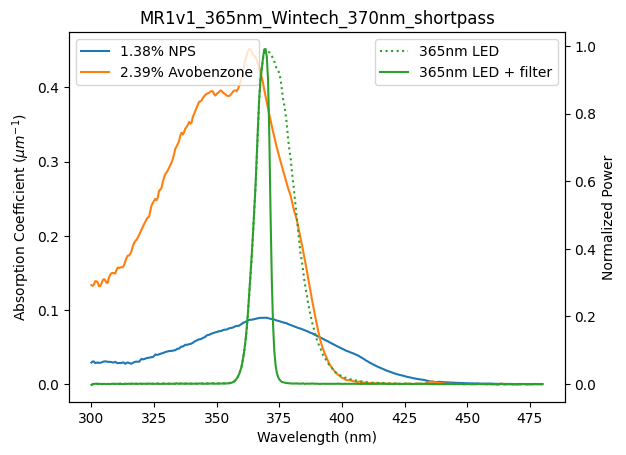

In [6]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), label='1.38% NPS')
ax.plot(wavelengths, resin_avobenzone.calc_absorption_coef_inv_um(wavelengths), label='2.39% Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.set_title(source_365nm_filtered.name)
ax2.plot(wavelengths, source_365nm.calc_power(wavelengths), c='C2', ls=':', label='365nm LED')
ax2.plot(wavelengths, source_365nm_filtered.calc_power(wavelengths), c='C2', label='365nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

## Compare 405nm LED spectra to absorbers

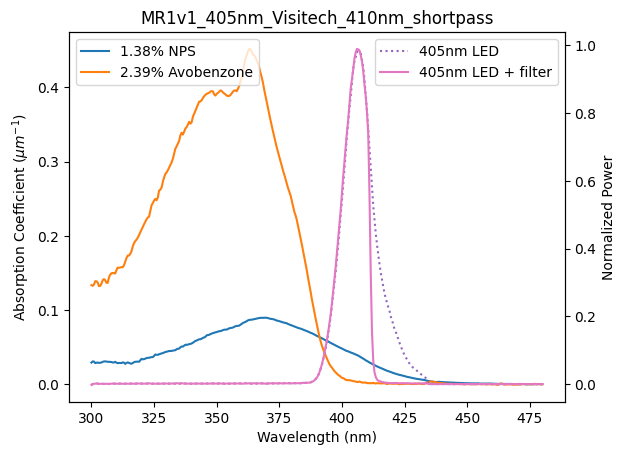

In [7]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), label='1.38% NPS')
ax.plot(wavelengths, resin_avobenzone.calc_absorption_coef_inv_um(wavelengths), label='2.39% Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.set_title(source_405nm_filtered.name)
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C4', ls=':', label='405nm LED')
ax2.plot(wavelengths, source_405nm_filtered.calc_power(wavelengths), c='C6', label='405nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

The 365nm source's absorbtion is dominated by the Avobenzone while the 405nm source's absorbtion is dominated by the NPS. Using this information, a dual wavlength resin can be formulated with differing penetration depths for each wavelength

# Final Resin Absorbtion

Text(0.5, 1.0, 'PEG-100__NPS-1.69_Avo-2.55__Irg-1')

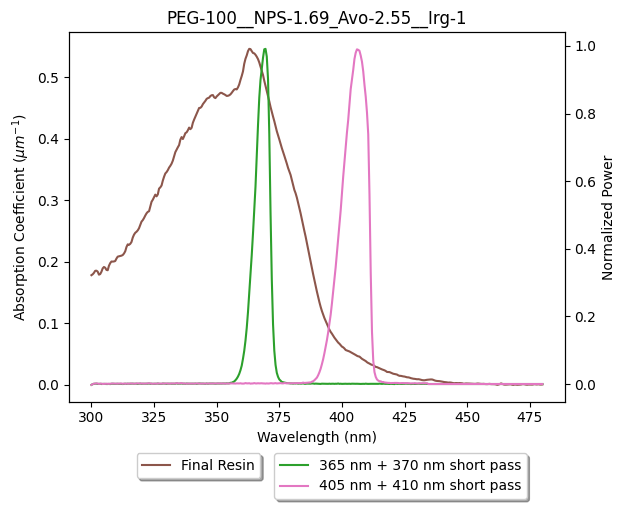

In [8]:
fig, ax = plt.subplots()
ln1 = ax.plot(wavelengths, resin_nps_avobenzone.calc_absorption_coef_inv_um(wavelengths), c='C5', label="Final Resin")
ax.set_xlabel('Wavelength (nm)', weight=500)
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)', weight=500)
# ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ln3 = ax2.plot(wavelengths, source_365nm_filtered.calc_power(wavelengths), c='C2', label='365 nm + 370 nm short pass')
ln4 = ax2.plot(wavelengths, source_405nm_filtered.calc_power(wavelengths), c='C6', label='405 nm + 410 nm short pass')
ax2.set_ylabel('Normalized Power', weight=500)
# ax2.legend(loc='upper right')

lns = ln1+ln3+ln4
labs = [l.get_label() for l in lns]
ax.legend(loc='upper right', bbox_to_anchor=(0.4, -0.12), ncol=1, fancybox=True, shadow=True)
ax2.legend(loc='upper left', bbox_to_anchor=(0.4, -0.12), ncol=1, fancybox=True, shadow=True)
# ax.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fancybox=True, shadow=True)

ax.set_title(resin_nps_avobenzone.name)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PEG-100__NPS-1.69_Avo-2.55__Irg-1\nMR1v1_405nm_Visitech_410nm_shortpass'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

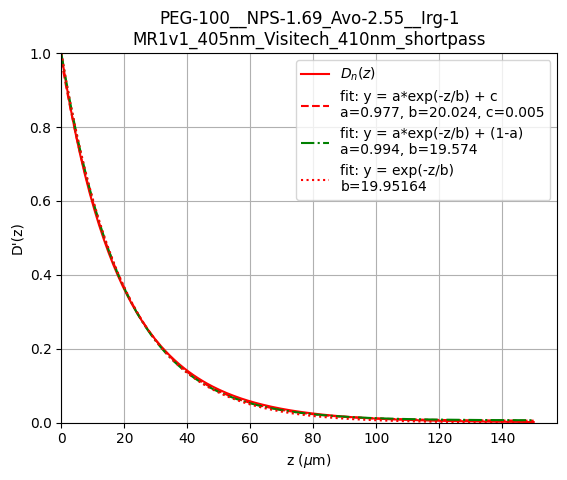

In [9]:
irradiance_405nm_filtered = Irradiance(
    source=source_405nm_filtered, 
    resin=resin_nps_avobenzone, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405nm_filtered = NormalizedDose(
    irradiance=irradiance_405nm_filtered, 
    z_array_params=z_array_params_15_0
)

norm_dose_405nm_filtered.plot(
    title=(
        resin_nps_avobenzone.name +
        "\n" +
        source_405nm_filtered.name
    )
)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PEG-100__NPS-1.69_Avo-2.55__Irg-1\nMR1v1_365nm_Wintech_370nm_shortpass'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

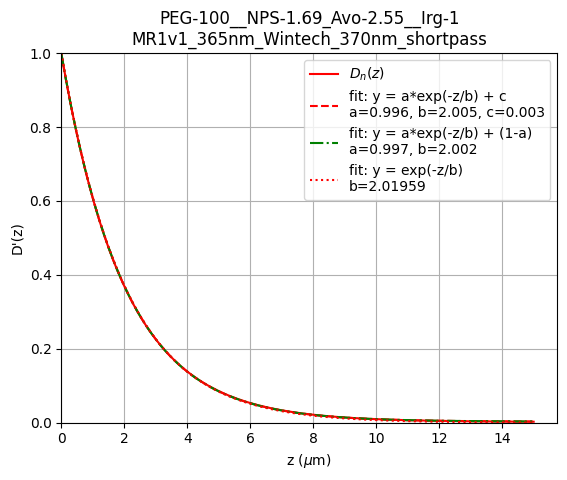

In [10]:
irradiance_365nm_filtered = Irradiance(
    source=source_365nm_filtered, 
    resin=resin_nps_avobenzone, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_365nm_filtered = NormalizedDose(
    irradiance=irradiance_365nm_filtered, 
    z_array_params=z_array_params_1_5
)

norm_dose_365nm_filtered.plot(
    title=(
        resin_nps_avobenzone.name +
        "\n" +
        source_365nm_filtered.name
    )
)

### Normalized layer thicknesses

In [11]:
15 / 20.024

0.7491010787055533

In [12]:
1.5 / 2.005

0.7481296758104738